In [4]:
%pip install numpy
%pip install matplotlib

from logging import WARNING, INFO
#from typing import Callable, Dict, List, Optional, Tuple, Union
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import cm

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 6.7 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.1 MB 6.3 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 6.8 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 7.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.2 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 5.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 8.4 MB/s eta 0:00:01
   ----------------------------------- ----

In [17]:
run_name = '/2025-06-09/16-16-04'
seed = '1999'

save_path = 'C:/Users/Iker/unibertsitatea/praktikak/GLow_poisoning/GLow-master/outputs/plots'
#file_path = 'outputs/no_pretrain/' + 'seed_' + seed + '/' + run_name #NEED TO READ ALL FILES
root = 'C:/Users/Iker/unibertsitatea/praktikak/GLow_poisoning/GLow-master/outputs'
file_path = root + run_name
num_agents = 7

In [7]:
tplgys = []
raw_tplgys = []
acc_distr = []
# Read file
file = open(file_path+'/0_pool.out', mode = 'r', encoding = 'utf-8-sig')
lines = file.readlines()
tplgys.append(lines)
file.close()
# Read file
file = open(file_path+'/raw.out', mode = 'r', encoding = 'utf-8-sig')
r_lines = file.readlines()
raw_tplgys.append(r_lines)
file.close()
# Read file
file = open(file_path+'/acc_distr.out', mode = 'r', encoding = 'utf-8-sig')
a_lines = file.readlines()
acc_distr.append(a_lines)
file.close()

In [8]:
tplgy_ID = []
loss = []
acc = []

for line in tplgys[0]:
    tplgy_ID.append(int(line.split(' ')[1]))
    loss.append(float(line.split(' ')[-3]))
    acc.append(float(line.split(' ')[-1]))
    
print(loss)
print(acc)

[0.20350529182178434, 0.21082115350145614, 0.6545969175058417, 1.4574375748634338, 0.9078925875946879, 1.50938356295228, 27.500345945358276]
[0.9971401334604385, 0.9974578964092787, 0.9917381633301557, 0.9939625039720369, 0.9895138226882746, 0.9939625039720369, 0.35398792500794407]


In [9]:
exec_times = []
for tplgy in raw_tplgys:
    exec_times.append(float(tplgy[-1].split(' ')[1])/60)
print(exec_times)

[64.89410690466563]


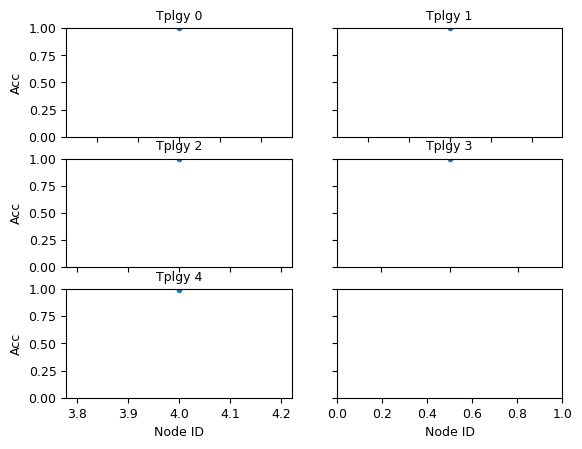

In [21]:
fig, axs = plt.subplots(3, 2)
axs[0, 0].plot(tplgy_ID[0], acc[0], '.')
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_title("Tplgy 0", fontsize=9)
axs[0, 1].plot(tplgy_ID[1], acc[1], '.')
axs[0, 1].set_ylim(0, 1)
axs[0, 1].set_title("Tplgy 1", fontsize=9)
axs[1, 0].plot(tplgy_ID[2], acc[2], '.')
axs[1, 0].set_ylim(0, 1)
axs[1, 0].set_title("Tplgy 2", fontsize=9)
axs[1, 1].plot(tplgy_ID[3], acc[3], '.')
axs[1, 1].set_ylim(0, 1)
axs[1, 1].set_title("Tplgy 3", fontsize=9)
axs[2, 0].plot(tplgy_ID[4], acc[4], '.')
axs[2, 0].set_ylim(0, 1)
axs[2, 0].set_title("Tplgy 4", fontsize=9)

for ax in axs.flat:
    ax.set(xlabel='Node ID', ylabel='Acc')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

plt.savefig(save_path+run_name+'_acc.pdf')

C:\Users\Iker\AppData\Local\Temp\ipykernel_21964\648617237.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 5)


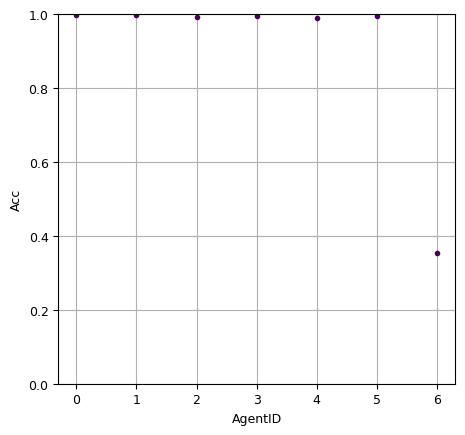

In [22]:
font = {'size': 9}
plt.rc('font', **font)
viridis = cm.get_cmap('viridis', 5)
plt.plot(tplgy_ID, acc, '.', color=viridis(0))
plt.ylim(0, 1.)
x = np.arange(0, num_agents, 1)
plt.xticks(x)
#plt.title("Tplgy 0", fontsize=9)
plt.xlabel('AgentID')
plt.ylabel('Acc')
plt.grid()

ax = plt.gca()
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
#lgd = ax.legend(['Tplgy 0', 'Tplgy 2', 'Tplgy 4', 'Tplgy 6', 'Tplgy 7'], loc='upper center',shadow=True, bbox_to_anchor=(0.5, -0.15), ncol = 5, fancybox= True)
plt.savefig(save_path+run_name+'_summarized_acc.pdf')#, bbox_extra_artists=(lgd,), bbox_inches='tight')

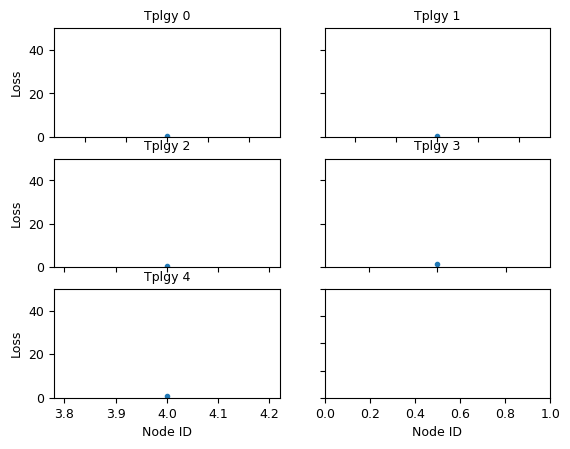

In [24]:
fig, axs = plt.subplots(3, 2)
axs[0, 0].plot(tplgy_ID[0], loss[0], '.')
axs[0, 0].set_ylim(0, 50)
axs[0, 0].set_title("Tplgy 0", fontsize=9)
axs[0, 1].plot(tplgy_ID[1], loss[1], '.')
axs[0, 1].set_ylim(0, 50)
axs[0, 1].set_title("Tplgy 1", fontsize=9)
axs[1, 0].plot(tplgy_ID[2], loss[2], '.')
axs[1, 0].set_ylim(0, 50)
axs[1, 0].set_title("Tplgy 2", fontsize=9)
axs[1, 1].plot(tplgy_ID[3], loss[3], '.')
axs[1, 1].set_ylim(0, 50)
axs[1, 1].set_title("Tplgy 3", fontsize=9)
axs[2, 0].plot(tplgy_ID[4], loss[4], '.')
axs[2, 0].set_ylim(0, 50)
axs[2, 0].set_title("Tplgy 4", fontsize=9)

for ax in axs.flat:
    ax.set(xlabel='Node ID', ylabel='Loss')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()

plt.savefig(save_path+run_name+'_loss.pdf')

In [235]:
print(loss)

[3.5364224910736084, 3.4492888785898685, 3.5509814508259296, 3.6035849824547768, 3.592090304940939, 3.6364270858466625, 3.5787828862667084, 3.5237152725458145, 11.081894993782043, 11.068373799324036]


C:\Users\Iker\AppData\Local\Temp\ipykernel_21964\1381615489.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 5)


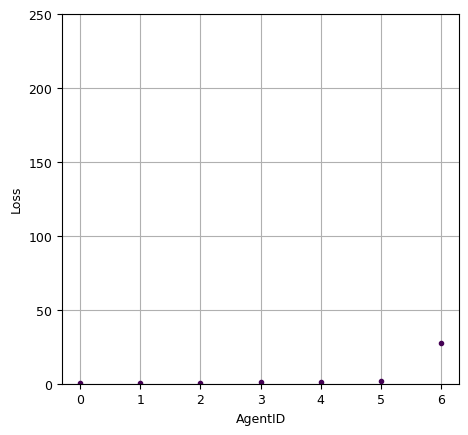

In [25]:
font = {'size': 9}
plt.rc('font', **font)
viridis = cm.get_cmap('viridis', 5)
plt.plot(tplgy_ID, loss, '.', color=viridis(0))
x = np.arange(0, num_agents, 1)
plt.xticks(x)
plt.ylim(0, 250)
#plt.title("Tplgy 0", fontsize=9)
plt.xlabel('AgentID')
plt.ylabel('Loss')
plt.grid()

ax = plt.gca()
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

#lgd = ax.legend(['Tplgy 0', 'Tplgy 2', 'Tplgy 4', 'Tplgy 6', 'Tplgy 7'], loc='upper center', shadow = True, bbox_to_anchor=(0.5, -0.15), ncol = 5, fancybox= True)

plt.savefig(save_path+run_name+'_summarized_loss.pdf')#, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [13]:
#VISUALIZE LOSSES PER TOPOLOGY AND AGENT
loss_per_tplgy = []
num_rounds = 20
    
tmp = raw_tplgys[0][1].split()
for i in range(1,num_rounds+1):
    loss_per_tplgy.append((float(tmp[2*i][:-1])))

In [14]:
print(loss_per_tplgy)

[27.49705183506012, 27.4446941614151, 0.23002776829525828, 0.9682979276403785, 23.115592658519745, 3.4084374755620956, 24.121143460273743, 27.50689160823822, 0.23850525938905776, 0.20480112977384124, 0.6630561234196648, 9.47871658205986, 1.2190036373212934, 9.7026606798172, 27.500345945358276, 0.20350529182178434, 0.21082115350145614, 0.6545969175058417, 1.4574375748634338, 0.9078925875946879]


In [27]:
#VISUALIZE LOSSES PER TOPOLOGY AND AGENT
loss_per_tplgy_by_agent = []
num_rounds = 20
for i in range(num_agents):
    tmp_loss = []
    for j in range(i+1, num_rounds, num_agents):
        tmp_loss.append((loss_per_tplgy[j]))
    loss_per_tplgy_by_agent.append(tmp_loss)

In [28]:
print(len(loss_per_tplgy_by_agent[0]))

3


C:\Users\Iker\AppData\Local\Temp\ipykernel_21964\2992372764.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('viridis', 10)
C:\Users\Iker\AppData\Local\Temp\ipykernel_21964\2992372764.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = cm.get_cmap('plasma', 10)


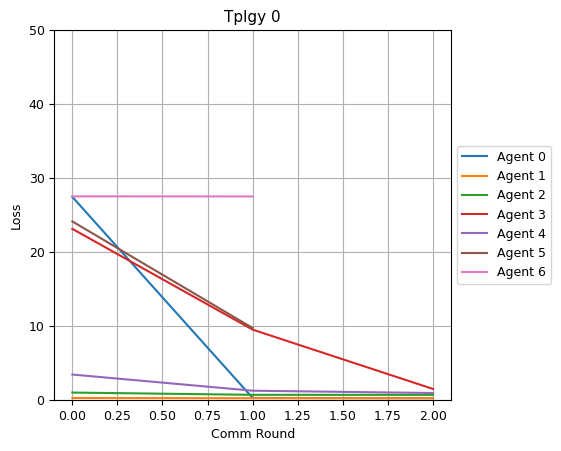

In [32]:
#VISUALIZE LOSSES PER TOPOLOGY AND AGENT
viridis = cm.get_cmap('viridis', 10)
plasma = cm.get_cmap('plasma', 10)
font = {'size': 9}
titles = ['Tplgy 0', 'Tplgy 2', 'Tplgy 4', 'Tplgy 6', 'Tplgy 7']

for i in range(1):
    plt.rc('font', **font)
    plt.plot(loss_per_tplgy_by_agent[0], color='tab:blue')
    plt.plot(loss_per_tplgy_by_agent[1], color='tab:orange')
    plt.plot(loss_per_tplgy_by_agent[2], color='tab:green')
    plt.plot(loss_per_tplgy_by_agent[3], color='tab:red')
    plt.plot(loss_per_tplgy_by_agent[4], color='tab:purple')
    plt.plot(loss_per_tplgy_by_agent[5], color='tab:brown')
    plt.plot(loss_per_tplgy_by_agent[6], color='tab:pink')
    plt.ylim(0, 50)
    plt.xlabel('Comm Round')
    plt.ylabel('Loss')
    plt.title(titles[i], fontsize=11)
    ax = plt.gca()
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(['Agent 0', 'Agent 1', 'Agent 2', 'Agent 3', 'Agent 4', 'Agent 5', 'Agent 6'], loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid()
    
    plt.savefig(save_path + run_name+'_raw_summarized_loss.pdf')
    plt.show()


In [242]:
# font = {'size': 5}
# plt.rc('font', **font)
# 
# #VISUALIZE LOSSES PER TOPOLOGY AND AGENT
# viridis = cm.get_cmap('viridis', 10)
# plasma = cm.get_cmap('plasma', 10)
# 
# fig, axs = plt.subplots()
# fig.tight_layout()
# 
# axs.plot(loss_per_tplgy_by_agent[0][:24], color=plasma(0.8))
# axs.plot(loss_per_tplgy_by_agent[1][:24], color=viridis(0.))
# axs.plot(loss_per_tplgy_by_agent[2][:24], color=viridis(0.1))
# axs.plot(loss_per_tplgy_by_agent[3][:24], color=viridis(0.2))
# axs.plot(loss_per_tplgy_by_agent[4][:24], color=plasma(0.7))
# axs.plot(loss_per_tplgy_by_agent[5][:24], color=viridis(0.3))
# axs.plot(loss_per_tplgy_by_agent[6][:24], color=viridis(0.4))
# axs.plot(loss_per_tplgy_by_agent[7][:24], color=viridis(0.5))
# axs.plot(loss_per_tplgy_by_agent[8][:24], color=viridis(0.85))
# axs.plot(loss_per_tplgy_by_agent[9][:24], color=plasma(0.4))
# axs.grid()
# axs.set_ylim(0, 250)
# #axs[0, 0].set_xlabel('Comm Round')
# #axs[0, 0].set_ylabel('Loss')
# axs.set_title("Tplgy 0", fontsize=6)
# 
# ax = plt.gca()
# box = ax.get_position()
# #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# lgd = ax.legend(['Agent 0 - ND', 'Agent 1 - R', 'Agent 2 - R', 'Agent 3 - R', 'Agent 4 - ND', 'Agent 5 - R', 'Agent 6 - R', 'Agent 7 - R', 'Agent 8 - D', 'Agent 9 - DND'], loc='upper center', shadow = True, bbox_to_anchor=(-0.15, -0.15), ncol = 5, fancybox= True)
# 
# plt.savefig(save_path+run_name+'_top_loss.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')
# plt.show()

In [243]:
# '''Visualize acc average per pool and comm round'''
# 
# acc1 = []
# for accuracies in acc_distr:
#     acc2 = []
#     for acc in accuracies:
#         res = []
#         for idx in acc.split(' '):
#             f_idx = float(idx)
#             if f_idx == 1.0:
#                 f_idx = 0.0
#             res.append(f_idx)
#         #res = [float(idx) for idx in acc.split(' ')]
#         if res == 1.0:
#             res = 0.0
#         acc2.append(np.average(res))
#     acc1.append(acc2)

In [244]:
# '''Create sets with exec times'''
# acc_per_nodes = []
# for i in range(num_agents):
#     tmp_tplgy = []
#     for j in range(5):
#         tmp_tplgy.append(acc1[j][i::10])
#     acc_per_nodes.append(tmp_tplgy)

In [245]:
# viridis = cm.get_cmap('viridis', 10)
# font = {'size': 9}
# for node in range(num_agents):
#     plt.rc('font', **font)
#     for i in range(5):
#         plt.plot(acc_per_nodes[node][i], color=viridis(0.1 * 2.*i))
#     #x = np.arange(0, num_rounds, 1)
#     #plt.xticks(x)
#     plt.ylim(0.0, 1.0)
#     plt.title('Node ' + str(node))
#     plt.xlabel('Comm Round')
#     plt.ylabel('Acc')
#     plt.grid()
# 
#     ax = plt.gca()
#     box = ax.get_position()
#     ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
#     ax.legend(['Tplgy 0', 'Tplgy 1', 'Tplgy 2', 'Tplgy 3', 'Tplgy 4'], loc='center left', bbox_to_anchor=(1, 0.5))
#     plt.savefig(save_path+'node'+ str(node) +'_distr_val_acc.pdf')
#     plt.show()

In [246]:
# '''Visualize Exec times per topology'''
# font = {'size': 9}
# plt.rc('font', **font)
# x = [0, 2, 4, 6, 7]
# plt.plot(x, exec_times, '.')
# plt.xticks(x)
# plt.title("Exec times " + run_name)
# plt.xlabel("tplgy")
# plt.ylabel("mins")
# plt.grid()
# plt.savefig(save_path+run_name+'_exec_times.pdf')
# plt.show()